In [2]:
%matplotlib widget

Compare to the other image

Normalize the CNR to fluence. \ image dose \ exposure

In [3]:
# %%
# Looking at the pepto images

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import mpl_interactions as pli

# Define the root directory to start the search
root_dir = './'

# Load .npy files
data_list, data_names = [], []
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            data_list.append(np.load(file_path))
            data_names.append(file_path)

# Sort data names and data list
data_list = [x for _, x in sorted(zip(data_names, data_list))]
data_names = sorted(data_names)

data_list = np.array(data_list)

for i, name in enumerate(data_names):
    print(i, name)

0 ./S1728_PeptoBismol_20_30_76_100_114_120/Bin1.npy
1 ./S1728_PeptoBismol_20_30_76_100_114_120/Bin2.npy
2 ./S1728_PeptoBismol_20_30_76_100_114_120/Bin3.npy
3 ./S1728_PeptoBismol_20_30_76_100_114_120/Bin4.npy
4 ./S1728_PeptoBismol_20_30_76_100_114_120/Bin5.npy
5 ./S1728_PeptoBismol_20_30_76_100_114_120/Bin6.npy
6 ./S1728_PeptoBismol_20_30_76_100_114_120/BinAll.npy
7 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin1.npy
8 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin2.npy
9 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin3.npy
10 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin4.npy
11 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin5.npy
12 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/Bin6.npy
13 ./S1728_PeptoBismol_AirScan_20_30_76_100_114_120/BinAll.npy
14 ./S1728_PeptoBismol_BiAtt_20_30_76_100_114_120/Bin1.npy
15 ./S1728_PeptoBismol_BiAtt_20_30_76_100_114_120/Bin2.npy
16 ./S1728_PeptoBismol_BiAtt_20_30_76_100_114_120/Bin3.npy
17 ./S1728_PeptoBismol_BiAtt_20

/tmp/ipykernel_1498483/537748706.py:38: RuntimeWarning: invalid value encountered in divide
  corrected_image = (image - dark_field) / flood_field
/tmp/ipykernel_1498483/537748706.py:38: RuntimeWarning: divide by zero encountered in divide
  corrected_image = (image - dark_field) / flood_field


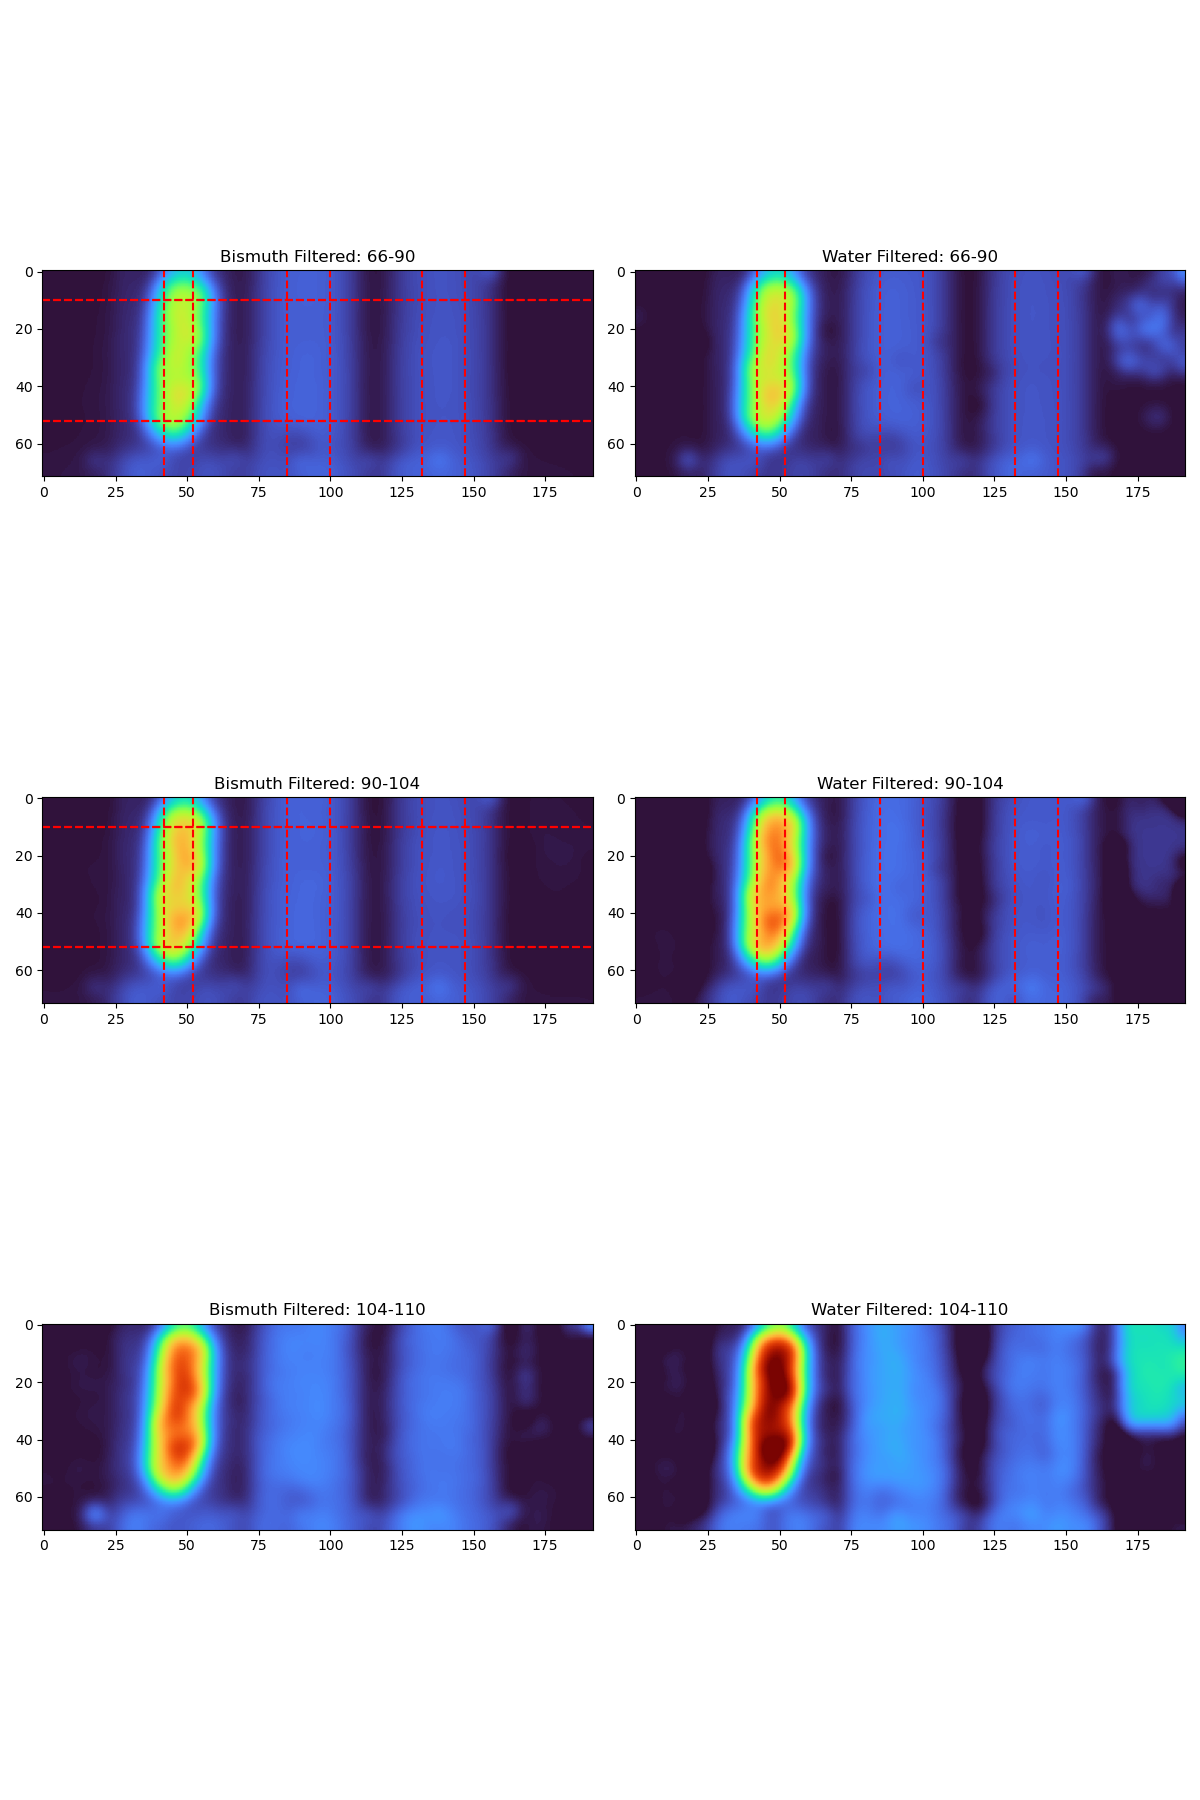

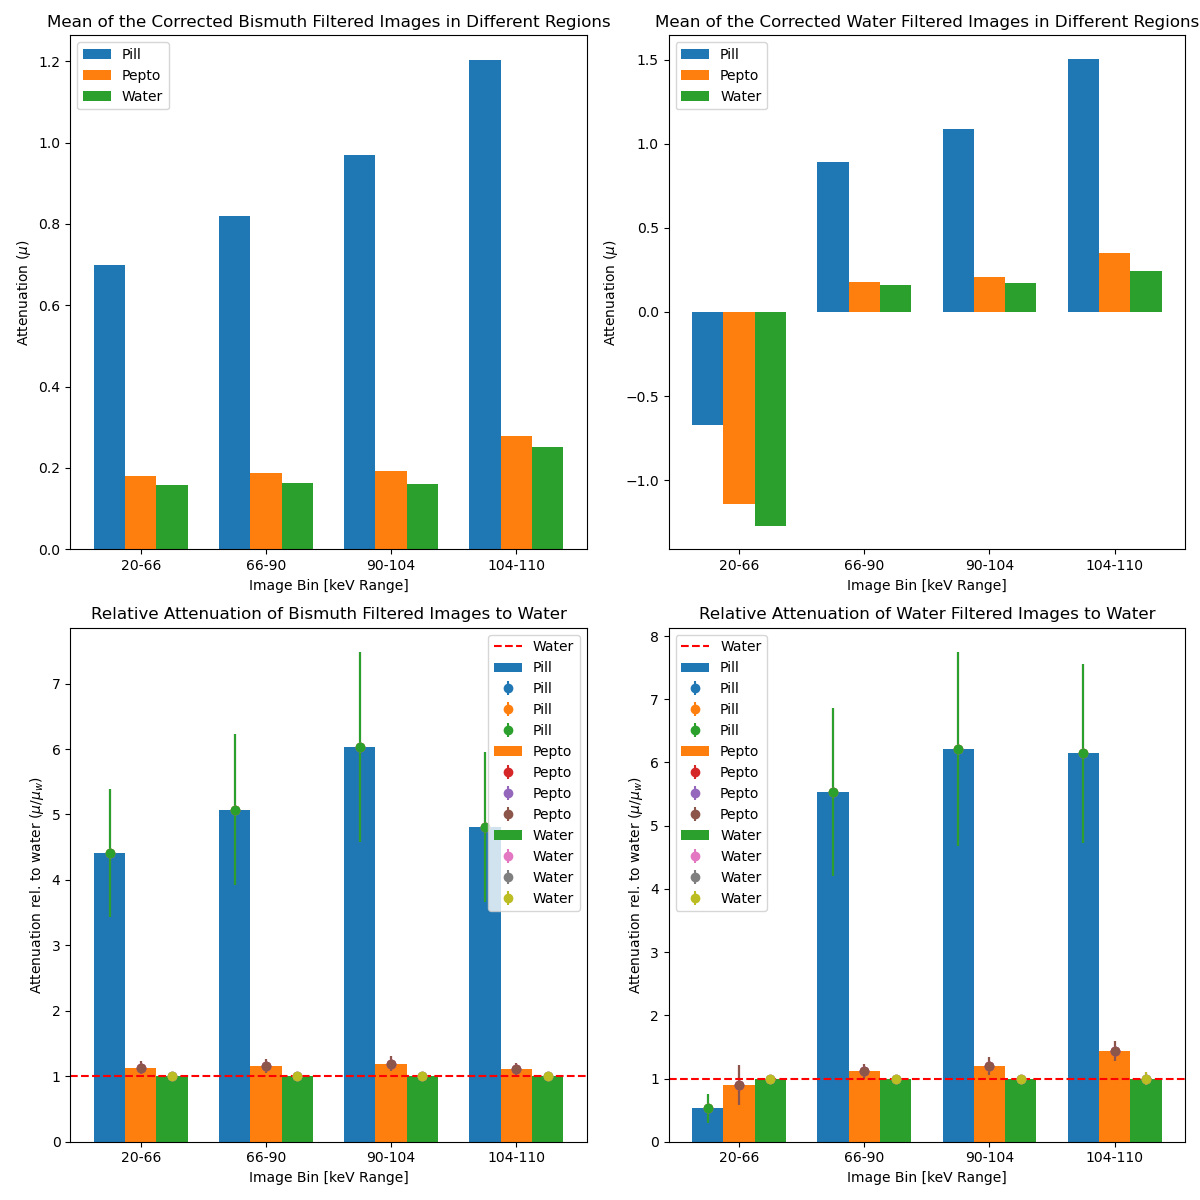

In [ ]:

# %%
# Define image groups
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
floods = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

# water_filtered = Original_test
# %%
# Function to detect and correct pixels
def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    corrected_image = image.copy()
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold

    def mean_of_neighbors(img, x, y):
        neighbors = [img[i, j] for i in range(max(0, x-1), min(img.shape[0], x+2))
                     for j in range(max(0, y-1), min(img.shape[1], y+2)) if (i, j) != (x, y)]
        return np.mean(neighbors)

    for x, y in np.argwhere(underresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    for x, y in np.argwhere(overresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)

    return corrected_image

# Function to correct images
def correct_images(images, darks, floods):
    corrected_images = []
    for i in range(6):
        dark_field, flood_field, image = darks[i], floods[i], images[i].copy()
        flood_field -= dark_field
        flood_field = flood_field / np.mean(flood_field[:15, 10:-10]) * np.mean(image[:15, 10:-10])
        corrected_image = (image - dark_field) / flood_field
        corrected_image = np.clip(corrected_image, 0.1, 4)
        corrected_image[np.isnan(corrected_image)] = 0.1

        mean, std = np.mean(corrected_image), np.std(corrected_image)
        # lower_threshold, upper_threshold = mean - 3*std, mean + 3*std
        # corrected_image = detect_and_correct_pixels(corrected_image, lower_threshold, upper_threshold)
        corrected_images.append(-np.log(corrected_image))

    return [gaussian_filter(image, 3) for image in corrected_images]

# Correct the bismuth_filtered and water_filteindianindianindianindianindianindianindianred images
corrected_bismuth = correct_images(bismuth_filtered, darks, floods)
corrected_water = correct_images(water_filtered, darks, floods)

# %%
# Plot the median of the corrected images
bins = np.array([20, 30, 76, 100, 114, 120]) - 10
names = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a figure with subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 18))

# Plot Bismuth Filtered images
for i in range(2,5):
    ax = axs[i-2, 0]
    ax.set_title(f'Bismuth Filtered: {names[i]}')
    im = ax.imshow(np.rot90(corrected_bismuth[i]), cmap='turbo', vmin=0., vmax=1.75)
    # fig.colorbar(im, ax=ax)

# Plot Water Filtered images
for i in range(2,5):
    ax = axs[i-2, 1]
    ax.set_title(f'Water Filtered: {names[i]}')
    im = ax.imshow(np.rot90(corrected_water[i]), cmap='turbo', vmin=0., vmax=1.75)
    # fig.colorbar(im, ax=ax)

# # Plot the median of the corrected images along a specific axis
# ax = axs[2, 0]
# for i in range(2,4):
#     ax.plot(np.mean(corrected_bismuth[i], axis=1), label=f'Bismuth: {names[i]}')
#     ax.plot(np.mean(corrected_water[i], axis=1), label=f'Water: {names[i]}')
# ax.set_aspect(20 * (corrected_bismuth[2].shape[0] / corrected_bismuth[2].shape[1]), adjustable='box')
# ax.legend()
# ax.set_title('Mean of the corrected images')

# # Hide the empty subplot
# axs[2, 1].axis('off')



# %%
# Bar chart of the mean of the regions
regions = [[42, 52], [85, 100], [132, 147]]
region_names = ['Pill', 'Pepto', 'Water']
for i in range(2):
    for j in range(3):
        axs[i, 0].axvline(regions[j][0], color='indianred', linestyle='--')
        axs[i, 0].axvline(regions[j][1], color='indianred', linestyle='--')
        axs[i, 1].axvline(regions[j][0], color='indianred', linestyle='--')
        axs[i, 1].axvline(regions[j][1], color='indianred', linestyle='--')

        # put lines at the top and bottom regions
        axs[i, 0].axhline(10, color='indianred', linestyle='--')
        axs[i, 0].axhline(corrected_bismuth[0].shape[1] - 20, color='indianred', linestyle='--')

plt.tight_layout()
# plt.show()

# Bar chart of mean values for specified regions
def plot_mean_values(corrected_images, title, ax):
    values = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) for j in range(1,5)]
        values.append(region_values)

    values = np.array(values)
    x = np.arange(1,5)
    width = 0.25

    for i in range(3):
        ax.bar(x + i * width, values[i], width, label=region_names[i])
    ax.set_xlabel('Image Bin [keV Range]')
    ax.set_ylabel('Attenuation ($\mu$)')
    ax.set_title(title)
    # ax.set_ylim(0,0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{name}' for name in names[1:5]])
    ax.legend()

# Bar chart of relative attenuation to water
def plot_relative_attenuation(corrected_images, title, ax):
    values = []
    stds = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-20]) for j in range(1,5)]
        region_std = [np.std(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-20]) for j in range(1,5)]
        values.append(region_values)
        stds.append(region_std)

    values = np.array(values)
    x = np.arange(1,5)
    width = 0.25

    
    for i in range(3):
        ax.bar(x + i * width, values[i], width, label=region_names[i])
        for j in range(3):
            ax.errorbar(x + i * width, values[i], yerr=np.abs(stds[i]), fmt='o', label=region_names[i
            ])
    ax.set_xlabel('Image Bin [keV Range]')
    ax.set_ylabel('Attenuation rel. to water ($\mu/\mu_w$)')
    ax.set_title(title)
    # ax.set_ylim(0,2)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{name}' for name in names[1:5]])
    ax.axhline(1, color='indianred', linestyle='--', label='Water')
    ax.legend()

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Plot mean values
plot_mean_values(corrected_bismuth, 'Mean of the Corrected Bismuth Filtered Images in Different Regions', axs[0, 0])
plot_mean_values(corrected_water, 'Mean of the Corrected Water Filtered Images in Different Regions', axs[0, 1])

# Plot relative attenuation
plot_relative_attenuation(corrected_bismuth, 'Relative Attenuation of Bismuth Filtered Images to Water', axs[1, 0])
plot_relative_attenuation(corrected_water, 'Relative Attenuation of Water Filtered Images to Water', axs[1, 1])

# plt.figure()
# plt.plot(np.mean(corrected_bismuth[2], axis=1), label='Pill')
# Plot the regions of interest over the images

plt.tight_layout()
# plt.show()

/tmp/ipykernel_1498483/2067135083.py:38: RuntimeWarning: invalid value encountered in divide
  corrected_image = (image - dark_field) / flood_field
/tmp/ipykernel_1498483/2067135083.py:38: RuntimeWarning: divide by zero encountered in divide
  corrected_image = (image - dark_field) / flood_field


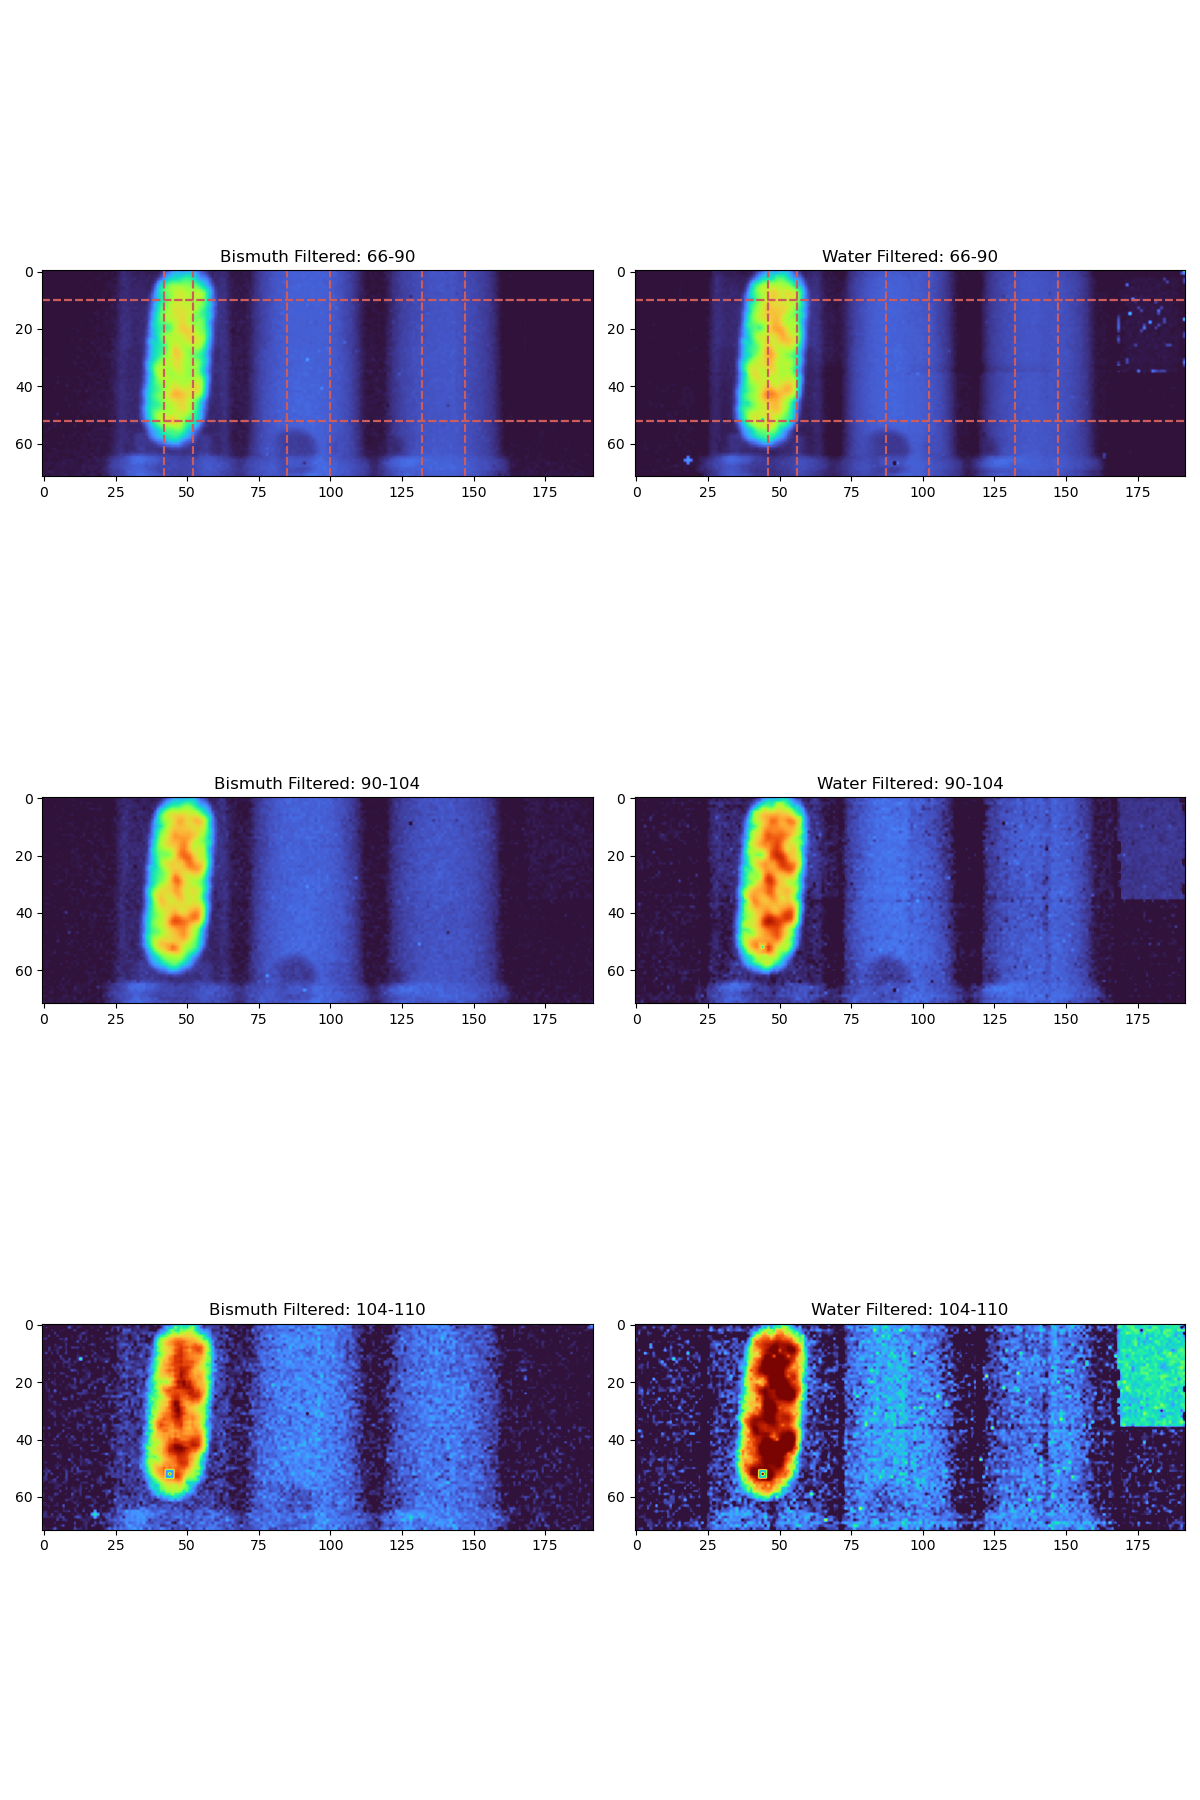

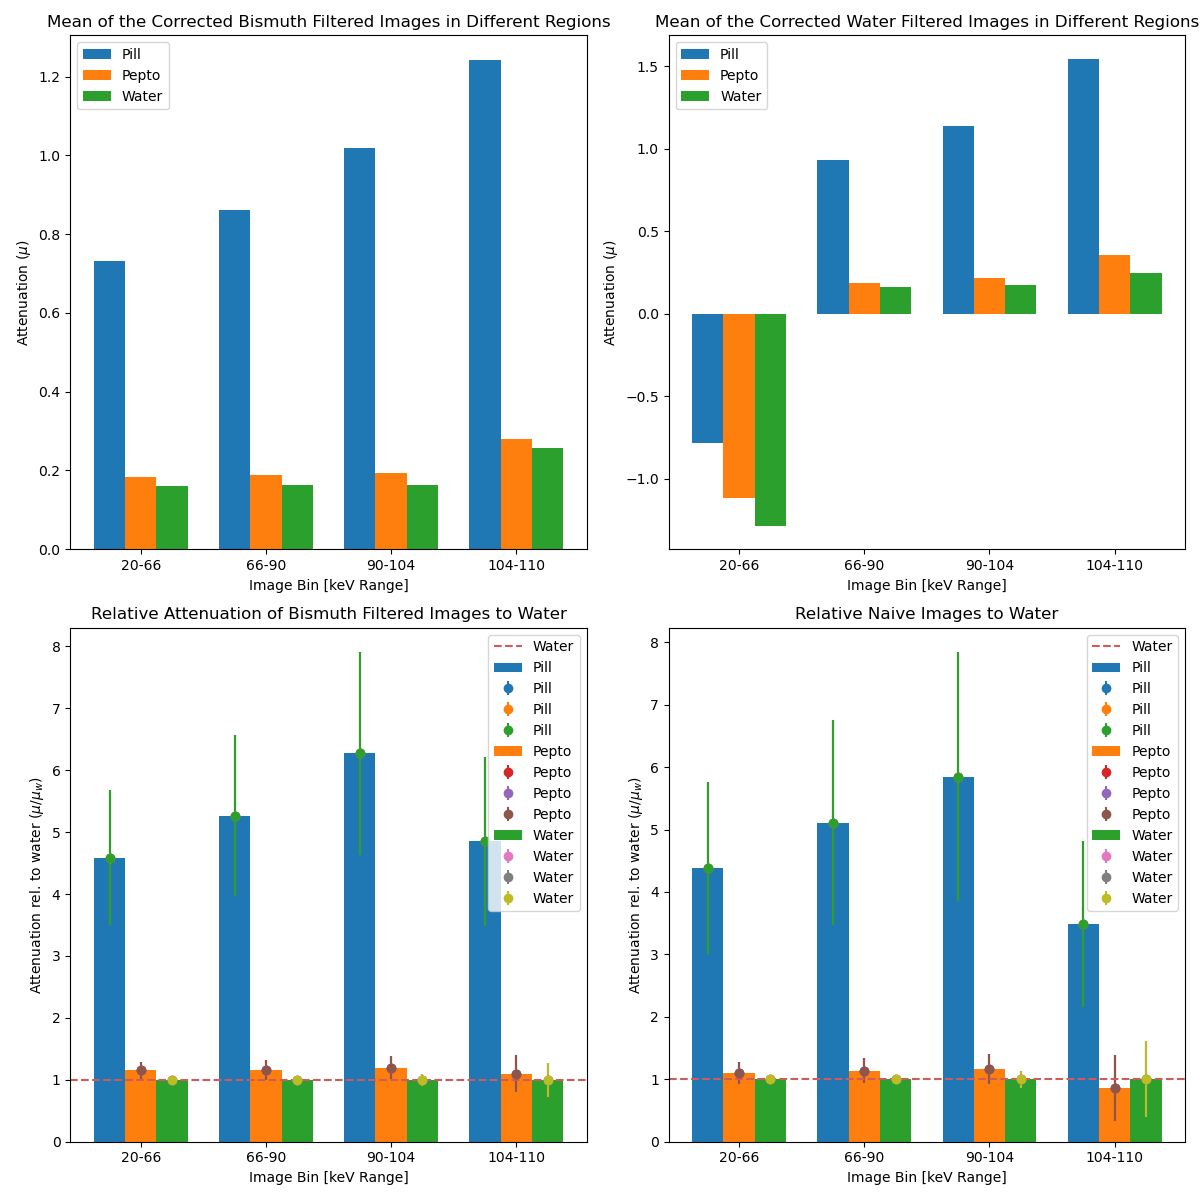

In [75]:

# %%
# Define image groups
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
floods = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

# water_filtered = Original_test
# %%
# Function to detect and correct pixels
def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    corrected_image = image.copy()
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold

    def mean_of_neighbors(img, x, y):
        neighbors = [img[i, j] for i in range(max(0, x-1), min(img.shape[0], x+2))
                     for j in range(max(0, y-1), min(img.shape[1], y+2)) if (i, j) != (x, y)]
        return np.mean(neighbors)

    for x, y in np.argwhere(underresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    for x, y in np.argwhere(overresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)

    return corrected_image

# Function to correct images
def correct_images(images, darks, floods):
    corrected_images = []
    for i in range(6):
        dark_field, flood_field, image = darks[i], floods[i], images[i].copy()
        flood_field -= dark_field
        flood_field = flood_field / np.mean(flood_field[:15, 10:-10]) * np.mean(image[:15, 10:-10])
        corrected_image = (image - dark_field) / flood_field
        corrected_image = np.clip(corrected_image, 0.1, 4)
        corrected_image[np.isnan(corrected_image)] = 0.1

        mean, std = np.mean(corrected_image), np.std(corrected_image)
        lower_threshold, upper_threshold = mean - 2*std, mean + 2*std
        corrected_image = detect_and_correct_pixels(corrected_image, lower_threshold, upper_threshold)
        corrected_images.append(-np.log(corrected_image))

    return [gaussian_filter(image, 0.1) for image in corrected_images]

# Correct the bismuth_filtered and water_filtered images
corrected_bismuth = correct_images(bismuth_filtered, darks, floods)
corrected_water = correct_images(water_filtered, darks, floods)
corrected_original = correct_images(Original_test, darks, floods)

# %%
# Plot the median of the corrected images
bins = np.array([20, 30, 76, 100, 114, 120]) - 10
names = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a figure with subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 18))

# Plot Bismuth Filtered images
for i in range(2,5):
    ax = axs[i-2, 0]
    ax.set_title(f'Bismuth Filtered: {names[i]}')
    im = ax.imshow(np.rot90(corrected_bismuth[i]), cmap='turbo', vmin=0., vmax=1.75)
    # fig.colorbar(im, ax=ax)

# Plot Water Filtered images
for i in range(2,5):
    ax = axs[i-2, 1]
    ax.set_title(f'Water Filtered: {names[i]}')
    im = ax.imshow(np.rot90(corrected_water[i]), cmap='turbo', vmin=0., vmax=1.75)


a,b,c = 4,2,0
# %%
# Bar chart of the mean of the regions
regions = [[42, 52], [85, 100], [132, 147]]
regions_2 = [[42+a, 52+a], [85+b, 100+b], [132+c, 147+c]]
region_names = ['Pill', 'Pepto', 'Water']
for i in range(2):
    for j in range(3):
        if i == 0:
            axs[0,i].axvline(regions[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions[j][1], color='indianred', linestyle='--')
            axs[0,i].axvline(regions[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions[j][1], color='indianred', linestyle='--')

            # put lines at the top and bottom regions
            axs[0,i].axhline(10, color='indianred', linestyle='--')
            axs[0,i].axhline(corrected_bismuth[0].shape[1] -20, color='indianred', linestyle='--')
        else:
            axs[0,i].axvline(regions_2[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][1], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][1], color='indianred', linestyle='--')

            # put lines at the top and bottom regions
            axs[0,i].axhline(10, color='indianred', linestyle='--')
            axs[0,i].axhline(corrected_bismuth[0].shape[1] -20, color='indianred', linestyle='--')

plt.tight_layout()
# plt.show()

# Bar chart of mean values for specified regions
def plot_mean_values(corrected_images, title, ax, regions):
    values = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) for j in range(1,5)]
        values.append(region_values)

    values = np.array(values)
    x = np.arange(1,5)
    width = 0.25

    for i in range(3):
        ax.bar(x + i * width, values[i], width, label=region_names[i])
    ax.set_xlabel('Image Bin [keV Range]')
    ax.set_ylabel('Attenuation ($\mu$)')
    ax.set_title(title)
    # ax.set_ylim(0,0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{name}' for name in names[1:5]])
    ax.legend()

# Bar chart of relative attenuation to water
def plot_relative_attenuation(corrected_images, title, ax, regions):
    values = []
    stds = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-20]) for j in range(1,5)]
        region_std = [np.std(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-20]) for j in range(1,5)]
        values.append(region_values)
        stds.append(region_std)

    values = np.array(values)
    x = np.arange(1,5)
    width = 0.25

    
    for i in range(3):
        ax.bar(x + i * width, values[i], width, label=region_names[i])
        for j in range(3):
            ax.errorbar(x + i * width, values[i], yerr=np.abs(stds[i]), fmt='o', label=region_names[i
            ])
    ax.set_xlabel('Image Bin [keV Range]')
    ax.set_ylabel('Attenuation rel. to water ($\mu/\mu_w$)')
    ax.set_title(title)
    # ax.set_ylim(0,2)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{name}' for name in names[1:5]])
    ax.axhline(1, color='indianred', linestyle='--', label='Water')
    ax.legend()

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Plot mean values
plot_mean_values(corrected_bismuth, 'Mean of the Corrected Bismuth Filtered Images in Different Regions', axs[0, 0], regions)
plot_mean_values(corrected_water, 'Mean of the Corrected Water Filtered Images in Different Regions', axs[0, 1], regions)
# plot_mean_values(corrected_original, 'Mean of the Naive in Different Regions', axs[0, 2], regions_2)


# Plot relative attenuation
plot_relative_attenuation(corrected_bismuth, 'Relative Attenuation of Bismuth Filtered Images to Water', axs[1, 0], regions)
plot_relative_attenuation(corrected_original, 'Relative Naive Images to Water', axs[1, 1], regions_2)

# plt.figure()
# plt.plot(np.mean(corrected_bismuth[2], axis=1), label='Pill')
# Plot the regions of interest over the images

plt.tight_layout()

print()

/tmp/ipykernel_1498483/514527040.py:38: RuntimeWarning: invalid value encountered in divide
  corrected_image = (image - dark_field) / flood_field
/tmp/ipykernel_1498483/514527040.py:38: RuntimeWarning: divide by zero encountered in divide
  corrected_image = (image - dark_field) / flood_field


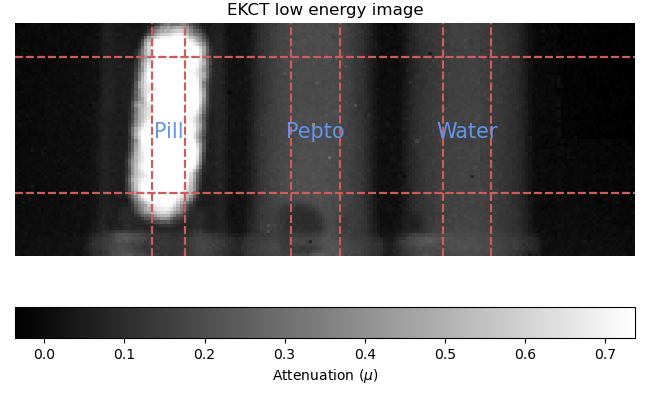

In [33]:

# %%
# Define image groups
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
floods = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

# water_filtered = Original_test
# %%
# Function to detect and correct pixels
def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    corrected_image = image.copy()
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold

    def mean_of_neighbors(img, x, y):
        neighbors = [img[i, j] for i in range(max(0, x-1), min(img.shape[0], x+2))
                     for j in range(max(0, y-1), min(img.shape[1], y+2)) if (i, j) != (x, y)]
        return np.mean(neighbors)

    for x, y in np.argwhere(underresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    for x, y in np.argwhere(overresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)

    return corrected_image

# Function to correct images
def correct_images(images, darks, floods):
    corrected_images = []
    for i in range(6):
        dark_field, flood_field, image = darks[i], floods[i], images[i].copy()
        flood_field -= dark_field
        flood_field = flood_field / np.mean(flood_field[:15, 10:-10]) * np.mean(image[:15, 10:-10])
        corrected_image = (image - dark_field) / flood_field
        corrected_image = np.clip(corrected_image, 0.1, 4)
        corrected_image[np.isnan(corrected_image)] = 0.1

        mean, std = np.mean(corrected_image), np.std(corrected_image)
        lower_threshold, upper_threshold = mean - 2*std, mean + 2*std
        corrected_image = detect_and_correct_pixels(corrected_image, lower_threshold, upper_threshold)
        corrected_images.append(-np.log(corrected_image))

    return [gaussian_filter(image, 0.1) for image in corrected_images]

# Correct the bismuth_filtered and water_filtered images
corrected_bismuth = correct_images(bismuth_filtered, darks, floods)
corrected_water = correct_images(water_filtered, darks, floods)
corrected_original = correct_images(Original_test, darks, floods)

# %%
# Plot the median of the corrected images
bins = np.array([20, 30, 76, 100, 114, 120]) - 10
names = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a figure with subplots
fig, axs = plt.subplots(1,1, figsize=(6.5,4))

# Plot Bismuth Filtered images
for i in range(2,3):
    ax = axs
    ax.set_title(f'EKCT low energy image')
    im = ax.imshow(np.rot90(corrected_bismuth[i]), cmap='gray', vmin=np.percentile(corrected_bismuth[i], 0.5), vmax=np.percentile(corrected_bismuth[i], 95))
    # fig.colorbar(im, ax=ax)

fig.colorbar(im, ax=ax, label='Attenuation ($\mu$)', orientation='horizontal')
plt.axis('off')
a,b,c = 4,2,0
# %%
# Bar chart of the mean of the regions
regions = [[42, 52], [85, 100], [132, 147]]
regions_2 = [[42+a, 52+a], [85+b, 100+b], [132+c, 147+c]]
region_names = ['Pill', 'Pepto', 'Water']
for i in range(1):
    for j in range(3):
        if i == 0:
            axs.axvline(regions[j][0], color='indianred', linestyle='--')
            axs.axvline(regions[j][1], color='indianred', linestyle='--')
            axs.axvline(regions[j][0], color='indianred', linestyle='--')
            axs.axvline(regions[j][1], color='indianred', linestyle='--')

            # put lines at the top and bottom regions
            axs.axhline(10, color='indianred', linestyle='--')
            axs.axhline(corrected_bismuth[0].shape[1] -20, color='indianred', linestyle='--')

            # put a label in between all the lines
            axs.text((regions[j][0] + regions[j][1]) / 2, 35, region_names[j], color='cornflowerblue', fontsize=15, ha='center')
        else:
            axs[0,i].axvline(regions_2[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][1], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][1], color='indianred', linestyle='--')

            # put lines at the top and bottom regions
            axs[0,i].axhline(10, color='indianred', linestyle='--')
            axs[0,i].axhline(corrected_bismuth[0].shape[1] -20, color='indianred', linestyle='--')


plt.tight_layout()
plt.savefig('EKCT_low_energy.png', dpi=300)

/tmp/ipykernel_1498483/4064361260.py:38: RuntimeWarning: invalid value encountered in divide
  corrected_image = (image - dark_field) / flood_field
/tmp/ipykernel_1498483/4064361260.py:38: RuntimeWarning: divide by zero encountered in divide
  corrected_image = (image - dark_field) / flood_field


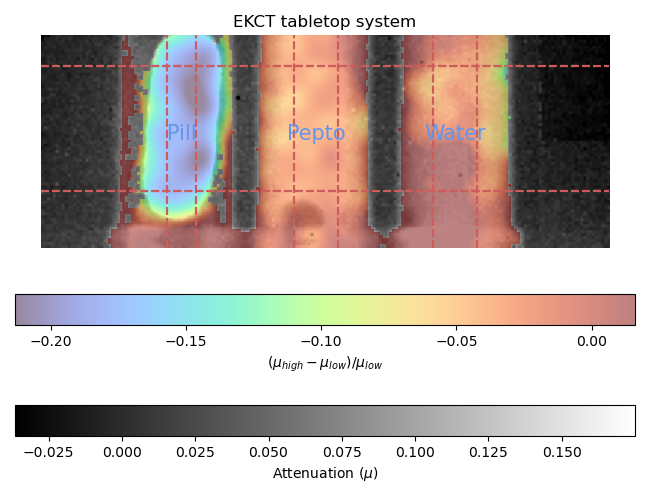

In [73]:

# %%
# Define image groups
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
floods = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

# water_filtered = Original_test
# %%
# Function to detect and correct pixels
def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    corrected_image = image.copy()
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold

    def mean_of_neighbors(img, x, y):
        neighbors = [img[i, j] for i in range(max(0, x-1), min(img.shape[0], x+2))
                     for j in range(max(0, y-1), min(img.shape[1], y+2)) if (i, j) != (x, y)]
        return np.mean(neighbors)

    for x, y in np.argwhere(underresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    for x, y in np.argwhere(overresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)

    return corrected_image

# Function to correct images
def correct_images(images, darks, floods):
    corrected_images = []
    for i in range(6):
        dark_field, flood_field, image = darks[i], floods[i], images[i].copy()
        flood_field -= dark_field
        flood_field = flood_field / np.mean(flood_field[:15, 10:-10]) * np.mean(image[:15, 10:-10])
        corrected_image = (image - dark_field) / flood_field
        corrected_image = np.clip(corrected_image, 0.1, 4)
        corrected_image[np.isnan(corrected_image)] = 0.1

        mean, std = np.mean(corrected_image), np.std(corrected_image)
        lower_threshold, upper_threshold = mean - 2*std, mean + 2*std
        corrected_image = detect_and_correct_pixels(corrected_image, lower_threshold, upper_threshold)
        corrected_images.append(-np.log(corrected_image))

    return [gaussian_filter(image, 0.1) for image in corrected_images]

# Correct the bismuth_filtered and water_filtered images
corrected_bismuth = correct_images(bismuth_filtered, darks, floods)
corrected_water = correct_images(water_filtered, darks, floods)
corrected_original = correct_images(Original_test, darks, floods)

# %%
# Plot the median of the corrected images
bins = np.array([20, 30, 76, 100, 114, 120]) - 10
names = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a figure with subplots
fig, axs = plt.subplots(1,1, figsize=(6.5,5))

# Plot Bismuth Filtered images
for i in range(2,3):
    ax = axs
    ax.set_title(f'EKCT tabletop system')
    image = np.rot90((gaussian_filter(corrected_bismuth[i],3) - gaussian_filter(corrected_bismuth[i+1],3))/gaussian_filter(corrected_bismuth[i],3))
    image[np.rot90(corrected_bismuth[i]) < 0.05] = np.NaN
    im = ax.imshow(np.rot90(corrected_bismuth[i]),vmin=np.nanpercentile(corrected_bismuth[i], 0.5), vmax=np.nanpercentile(corrected_bismuth[i], 80), cmap='gray')
    im2 = ax.imshow(image, cmap='turbo', vmin=np.nanpercentile(image, 0.5), vmax=np.nanpercentile(image, 80),alpha=0.5)
    # fig.colorbar(im, ax=ax)

fig.colorbar(im, ax=ax, label='Attenuation ($\mu$)', orientation='horizontal')
fig.colorbar(im2, ax=ax, label='($\mu_{high} - \mu_{low})/\mu_{low}$', orientation='horizontal')
plt.axis('off')
a,b,c = 4,2,0
# %%
# Bar chart of the mean of the regions
regions = [[42, 52], [85, 100], [132, 147]]
regions_2 = [[42+a, 52+a], [85+b, 100+b], [132+c, 147+c]]
region_names = ['Pill', 'Pepto', 'Water']
for i in range(1):
    for j in range(3):
        if i == 0:
            axs.axvline(regions[j][0], color='indianred', linestyle='--')
            axs.axvline(regions[j][1], color='indianred', linestyle='--')
            axs.axvline(regions[j][0], color='indianred', linestyle='--')
            axs.axvline(regions[j][1], color='indianred', linestyle='--')

            # put lines at the top and bottom regions
            axs.axhline(10, color='indianred', linestyle='--')
            axs.axhline(corrected_bismuth[0].shape[1] -20, color='indianred', linestyle='--')

            # put a label in between all the lines
            axs.text((regions[j][0] + regions[j][1]) / 2, 35, region_names[j], color='cornflowerblue', fontsize=15, ha='center')
        else:
            axs[0,i].axvline(regions_2[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][1], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][0], color='indianred', linestyle='--')
            axs[0,i].axvline(regions_2[j][1], color='indianred', linestyle='--')

            # put lines at the top and bottom regions
            axs[0,i].axhline(10, color='indianred', linestyle='--')
            axs[0,i].axhline(corrected_bismuth[0].shape[1] -20, color='indianred', linestyle='--')


plt.tight_layout()
plt.savefig('EKCT_low_energy.png', dpi=300)

In [79]:


# Bar chart of relative attenuation to water
def report_relative_attenuation(corrected_images, title, ax, regions):
    values = []
    stds = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-20]) for j in range(1,5)]
        region_std = [np.std(corrected_images[j][regions[i][0]:regions[i][1], 10:-20]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-20]) for j in range(1,5)]
        values.append(region_values)
        stds.append(region_std)

    values = np.array(values)
    x = np.arange(1,5)
    width = 0.25

    # pretty print the values and standard_deviation in a table
    df = pd.DataFrame(values, columns=[f'{name}' for name in names[1:5]], index=region_names)
    print(title)
    print(df)
    print()

    std_df = pd.DataFrame(stds, columns=[f'{name}' for name in names[1:5]], index=region_names)
    print(std_df)
    print()

    return df, std_df

bismuth_filt_df, bimsuth_std = report_relative_attenuation(corrected_bismuth, 'Relative Attenuation of Bismuth Filtered Images to Water', axs[1, 0], regions)
water_filt_df, water_std = report_relative_attenuation(corrected_water, 'Relative Attenuation of Water Filtered Images to Water', axs[1, 1], regions)
unfilt_df, unfilt_std = report_relative_attenuation(corrected_original, 'Relative Naive Images to Water', axs[1, 1], regions_2)


cnr = (np.abs(bismuth_filt_df['66-90']['Pill'] - water_filt_df['90-104']['Pill'])/(bismuth_filt_df['66-90']['Pill'])) / np.sqrt(bimsuth_std['66-90']['Pill']**2 + water_std['90-104']['Pill']**2)

cnr_baseline = (np.abs(unfilt_df['66-90']['Pill'] - unfilt_df['90-104']['Pill'])/(unfilt_df['66-90']['Pill'])) / np.sqrt(bimsuth_std['66-90']['Pill']**2 + unfilt_std['90-104']['Pill']**2)

print(f'CNR estimated: {cnr}')
print(f'CNR baseline: {cnr_baseline}')

# Estimate the contrast for the pill region
contrast = (np.abs(bismuth_filt_df['66-90']['Pill'] - water_filt_df['90-104']['Pill']))

contrast_baseline = (np.abs(unfilt_df['66-90']['Pill'] - unfilt_df['90-104']['Pill']))

print(f'Contrast estimated: {contrast}')
print(f'Contrast baseline: {contrast_baseline}')

# Estimate the contrast for the Pepto region
HU = (np.abs(water_filt_df['20-66']['Pepto'] - water_filt_df['20-66']['Water']))/water_filt_df['20-66']['Water']*1000

# contrast_baseline = (np.abs(unfilt_df['66-90']['Pill'] - unfilt_df['90-104']['Pill']))

print(f'Contrast estimated pepto: {HU}')

# Estimate the contrast for the Pepto region
HU = (np.abs(water_filt_df['20-66']['Pepto'] - water_filt_df['20-66']['Water']))/water_filt_df['20-66']['Water']*1000

# contrast_baseline = (np.abs(unfilt_df['66-90']['Pill'] - unfilt_df['90-104']['Pill']))

print(f'Contrast estimated conv: {HU}')

# # Estimate the contrast for the Pepto region
# HU = (np.abs(bismuth_filt_df['20-66']['Pepto'] - bismuth_filt_df['20-66']['Water']))/bismuth_filt_df['20-66']['Water']*1000

# # contrast_baseline = (np.abs(unfilt_df['66-90']['Pill'] - unfilt_df['90-104']['Pill']))

# print(f'Contrast estimated pepto: {HU}')
# print(f'Contrast baseline: {contrast_baseline}')

# plt.figure()
# plt.plot(np.mean(corrected_bismuth[2], axis=1), label='Pill')
# Plot the regions of interest over the images
# plt.tight_layout()
# print()

Relative Attenuation of Bismuth Filtered Images to Water
          20-66     66-90    90-104   104-110
Pill   4.585776  5.265704  6.269218  4.848708
Pepto  1.151283  1.152534  1.195908  1.096597
Water  1.000000  1.000000  1.000000  1.000000

          20-66     66-90    90-104   104-110
Pill   1.087220  1.296717  1.633860  1.360958
Pepto  0.141868  0.162951  0.181210  0.296475
Water  0.039768  0.052310  0.094769  0.271013

Relative Attenuation of Water Filtered Images to Water
          20-66     66-90    90-104   104-110
Pill   0.608336  5.753624  6.470467  6.329329
Pepto  0.870067  1.145057  1.229878  1.444016
Water  1.000000  1.000000  1.000000  1.000000

          20-66     66-90    90-104   104-110
Pill  -0.803661  1.486358  1.722716  1.696036
Pepto -0.547855  0.166899  0.230285  0.516644
Water -0.335782  0.048715  0.192157  0.520308

Relative Naive Images to Water
          20-66     66-90    90-104   104-110
Pill   4.378276  5.109533  5.848205  3.489448
Pepto  1.095145  1.138545

/tmp/ipykernel_1498483/3354618816.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  HU = (np.abs(water - pepto))/water*1000


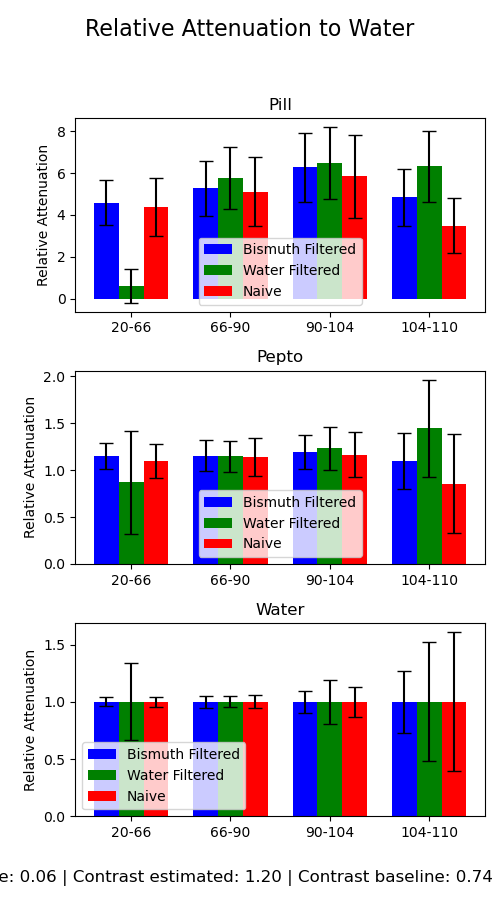

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data from the provided tables
bismuth_filt_df = pd.DataFrame({
    '20-66': [4.585261, 1.151200, 1.000000],
    '66-90': [5.265704, 1.152534, 1.000000],
    '90-104': [6.269218, 1.195908, 1.000000],
    '104-110': [4.848708, 1.096597, 1.000000]
}, index=['Pill', 'Pepto', 'Water'])

bismuth_std = pd.DataFrame({
    '20-66': [1.087430, 0.141859, 0.039697],
    '66-90': [1.296717, 0.162951, 0.052310],
    '90-104': [1.633860, 0.181210, 0.094769],
    '104-110': [1.360958, 0.296475, 0.271013]
}, index=['Pill', 'Pepto', 'Water'])

water_filt_df = pd.DataFrame({
    '20-66': [0.608341, 0.870074, 1.000000],
    '66-90': [5.753624, 1.145057, 1.000000],
    '90-104': [6.470467, 1.229878, 1.000000],
    '104-110': [6.329329, 1.444016, 1.000000]
}, index=['Pill', 'Pepto', 'Water'])

water_std = pd.DataFrame({
    '20-66': [0.803667, 0.547859, 0.335812],
    '66-90': [1.486358, 0.166899, 0.048715],
    '90-104': [1.722716, 0.230285, 0.192157],
    '104-110': [1.696036, 0.516644, 0.520308]
}, index=['Pill', 'Pepto', 'Water'])

unfilt_df = pd.DataFrame({
    '20-66': [4.378006, 1.095075, 1.000000],
    '66-90': [5.109533, 1.138545, 1.000000],
    '90-104': [5.848205, 1.164750, 1.000000],
    '104-110': [3.489448, 0.856143, 1.000000]
}, index=['Pill', 'Pepto', 'Water'])

unfilt_std = pd.DataFrame({
    '20-66': [1.378567, 0.178578, 0.042703],
    '66-90': [1.642424, 0.198748, 0.058520],
    '90-104': [1.989837, 0.237403, 0.132520],
    '104-110': [1.324328, 0.529932, 0.607910]
}, index=['Pill', 'Pepto', 'Water'])

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(5,9))
fig.suptitle('Relative Attenuation to Water', fontsize=16)

# Function to plot bar charts with error bars
def plot_bars(ax, df1, df2, df3, std1, std2, std3, title):
    x = np.arange(len(df1.columns))
    width = 0.25
    
    ax.bar(x - width, df1.loc[title], width, label='Bismuth Filtered', color='b', yerr=np.abs(std1.loc[title]), capsize=5)
    ax.bar(x, df2.loc[title], width, label='Water Filtered', color='g', yerr=np.abs(std2.loc[title]), capsize=5)
    ax.bar(x + width, df3.loc[title], width, label='Naive', color='r', yerr=np.abs(std3.loc[title]), capsize=5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(df1.columns)
    ax.set_title(title)
    ax.legend()
    ax.set_ylabel('Relative Attenuation')

# Plotting the data
plot_bars(axs[0], bismuth_filt_df, water_filt_df, unfilt_df, bismuth_std, water_std, unfilt_std, 'Pill')
plot_bars(axs[1], bismuth_filt_df, water_filt_df, unfilt_df, bismuth_std, water_std, unfilt_std, 'Pepto')
plot_bars(axs[2], bismuth_filt_df, water_filt_df, unfilt_df, bismuth_std, water_std, unfilt_std, 'Water')

# Annotations for CNR and contrast
cnr = 0.1061096646864527
cnr_baseline = 0.06086887139868816
contrast = 1.204763401201439
contrast_baseline = 0.7386720427339872
contrast_pepto = 129.9257156845608

fig.text(0.5, 0.02, f'CNR estimated: {cnr:.2f} | CNR baseline: {cnr_baseline:.2f} | Contrast estimated: {contrast:.2f} | Contrast baseline: {contrast_baseline:.2f} | Contrast estimated pepto: {contrast_pepto:.2f}', ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

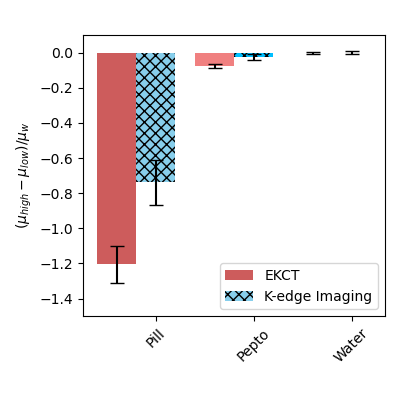

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data from the provided tables
bismuth_filt_df = pd.DataFrame({
    '20-66': [4.585261, 1.151200, 1.000000],
    '66-90': [5.265704, 1.152534, 1.000000],
    '90-104': [6.269218, 1.195908, 1.000000],
    '104-110': [4.848708, 1.096597, 1.000000]
}, index=['Pill', 'Pepto', 'Water'])

bismuth_std = pd.DataFrame({
    '20-66': [1.087430, 0.141859, 0.039697],
    '66-90': [1.296717, 0.162951, 0.052310],
    '90-104': [1.633860, 0.181210, 0.094769],
    '104-110': [1.360958, 0.296475, 0.271013]
}, index=['Pill', 'Pepto', 'Water'])

water_filt_df = pd.DataFrame({
    '20-66': [0.608341, 0.870074, 1.000000],
    '66-90': [5.753624, 1.145057, 1.000000],
    '90-104': [6.470467, 1.229878, 1.000000],
    '104-110': [6.329329, 1.444016, 1.000000]
}, index=['Pill', 'Pepto', 'Water'])

water_std = pd.DataFrame({
    '20-66': [0.803667, 0.547859, 0.335812],
    '66-90': [1.486358, 0.166899, 0.048715],
    '90-104': [1.722716, 0.230285, 0.192157],
    '104-110': [1.696036, 0.516644, 0.520308]
}, index=['Pill', 'Pepto', 'Water'])

unfilt_df = pd.DataFrame({
    '20-66': [4.378006, 1.095075, 1.000000],
    '66-90': [5.109533, 1.138545, 1.000000],
    '90-104': [5.848205, 1.164750, 1.000000],
    '104-110': [3.489448, 0.856143, 1.000000]
}, index=['Pill', 'Pepto', 'Water'])

unfilt_std = pd.DataFrame({
    '20-66': [1.378567, 0.178578, 0.042703],
    '66-90': [1.642424, 0.198748, 0.058520],
    '90-104': [1.989837, 0.237403, 0.132520],
    '104-110': [1.324328, 0.529932, 0.607910]
}, index=['Pill', 'Pepto', 'Water'])

# Calculate the differences between the 66-90 and 90-104 energy bins
bismuth_diff = (bismuth_filt_df['66-90'] - water_filt_df['90-104'])#/unfilt_df['66-90']*water_filt_df['66-90']
# water_diff = water_filt_df['66-90'] - water_filt_df['90-104']
unfilt_diff = (unfilt_df['66-90'] - unfilt_df['90-104'])#/unfilt_df['66-90']*water_filt_df['66-90'] 

bismuth_diff_std = np.sqrt(bismuth_std['66-90']**2 + bismuth_std['90-104']**2)/20
# water_diff_std = np.sqrt(water_std['66-90']**2 + water_std['90-104']**2)
unfilt_diff_std = np.sqrt(unfilt_std['66-90']**2 + unfilt_std['90-104']**2)/20

# Plotting
fig, axs = plt.subplots(1,1, figsize=(4,4))
# fig.suptitle('Difference in Relative Attenuation between 66-90 and 90-104 Energy Bins', fontsize=16)

# Function to plot bar charts with error bars
def plot_diff_bars(ax, diff, diff_std, title,off = 0,i=0,colors = ['indianred', 'lightcoral', 'r']):
    x = np.arange(len(diff)) + off
    width = 0.4
    labels = diff.index
    # colors = ['indianred', 'lightcoral', 'r']
    
    hash_patterns = ['', '\\', 'x']

    ax.bar(x, diff, width, color=colors, yerr=diff_std, capsize=5, hatch=hash_patterns[i]*3,label=title)
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    # ax.set_title(title)
    ax.set_ylabel('$(\mu_{high} - \mu_{low})/\mu_w$')
    ax.set_ylim(-1.5,0.1)

# Plotting the data
plot_diff_bars(axs, bismuth_diff, bismuth_diff_std, 'EKCT')
# plot_diff_bars(axs[1], water_diff, water_diff_std, 'Water Filtered Images')
plot_diff_bars(axs, unfilt_diff, unfilt_diff_std, 'K-edge Imaging',off=0.4,i=2,colors=['skyblue', 'deepskyblue', 'dodgerblue'])

plt.legend()
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

plt.savefig('diff.png',dpi=300)

In [6]:
import numpy as np
from scipy.optimize import minimize

def calculate_cnr(weights, ims_bismuth, ims_water):
    alpha, beta, gamma, alpha2, beta2, gamma2 = weights
    
    region_b = alpha * ims_bismuth[0] + beta * ims_bismuth[1] + gamma * ims_bismuth[2] + alpha2 * ims_bismuth[3] + beta2 * ims_bismuth[4] + gamma2 * ims_bismuth[5]
    # Want this to have high contrast
    region_w = alpha * ims_water[0] + beta * ims_water[1] + gamma * ims_water[2] + alpha2 * ims_water[3] + beta2 * ims_water[4] + gamma2 * ims_water[5]
    # Want this to have low signal
    # Minimize signal to noise ratio in the water region
    
    mu_w = np.mean(region_w)
    mu_b = np.mean(region_b)
    sigma_w = np.std(region_w)
    sigma_b = np.std(region_b)
    
    cnr = np.abs(mu_b - mu_w) / np.sqrt(sigma_b**2 + sigma_w**2)
    snr = np.abs(mu_w) / sigma_w
    return -cnr + snr  # Negative CNR for minimization

def optimize_cnr(ims_bismuth, ims_water):
    initial_weights = [1,1,1,-1,-1,1]  # Initial weights for the optimization
    bounds = [(-4, 4)] * 6  # Bounds for the weights (assuming they are between 0 and 1)
    
    result = minimize(calculate_cnr, initial_weights, args=(ims_bismuth, ims_water), bounds=bounds, method='Nelder-Mead')
    
    optimized_weights = result.x
    max_cnr = -result.fun  # Convert back to positive CNR
    
    return optimized_weights, max_cnr

regions = [[25, 50], [75, 90], [120, 140]]
region_names = ['Pill', 'Pepto', 'Water']

a, b = 95, 105
c,d = 20,-20
# Example usage with synthetic data
im1 = corrected_water[2][a:b,c:d]
im2 = corrected_water[3][a:b,c:d]
im3 = corrected_water[4][a:b,c:d]
im4 = corrected_bismuth[2][a:b,c:d]
im5 = corrected_bismuth[3][a:b,c:d]
im6 = corrected_bismuth[4][a:b,c:d]

ims_bismuth = [im1, im2, im3, im4, im5, im6]

e, f = 100, 180
g,h = 20,-20

im1_w = corrected_water[2][e:f,g:h]
im2_w = corrected_water[3][e:f,g:h]
im3_w = corrected_water[4][e:f,g:h]
im4_w = corrected_bismuth[2][e:f,g:h]
im5_w = corrected_bismuth[3][e:f,g:h]
im6_w = corrected_bismuth[4][e:f,g:h]

ims_water = [im1_w, im2_w, im3_w, im4_w, im5_w, im6_w]

optimized_weights, max_cnr = optimize_cnr(ims_bismuth, ims_water)
print("Optimized Weights:", optimized_weights)
print("Maximized CNR:", max_cnr)


Optimized Weights: [ 4. -4. -4.  4.  4.  4.]
Maximized CNR: 0.2011697464114675


In [4]:

# plot the image with the optimized weights
region_w = optimized_weights[0] * corrected_water[2] + optimized_weights[1] * corrected_water[3] + optimized_weights[2] * corrected_water[4] + optimized_weights[3] * corrected_bismuth[2] + optimized_weights[4] * corrected_bismuth[3] + optimized_weights[5] * corrected_bismuth[4]
region_b = optimized_weights[0] * corrected_water[2] + optimized_weights[1] * corrected_water[3] + optimized_weights[2] * corrected_water[4] + optimized_weights[3] * corrected_bismuth[2] + optimized_weights[4] * corrected_bismuth[3] + optimized_weights[5] * corrected_bismuth[4]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(region_w[:-20], cmap='turbo', vmin=np.percentile(region_w[:-20], 5), vmax=np.percentile(region_w[:-20], 80))
axs[0].set_title('Water Region')
axs[1].imshow(region_b[:-20], cmap='turbo', vmin=np.percentile(region_b[:-20], 5), vmax=np.percentile(region_b[:-20], 80))   
axs[1].set_title('Bismuth Region')

NameError: name 'optimized_weights' is not defined

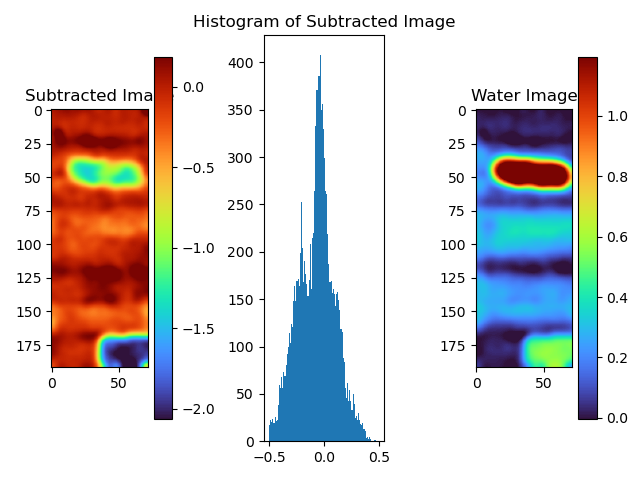

In [5]:
plt.figure()

corrected_bismuth[3] = corrected_bismuth[2]/ np.mean(corrected_bismuth[2][130:140,20:-20])
corrected_water[3] = corrected_water[3]/ np.mean(corrected_water[3][130:140,20:-20])
subtracted = (corrected_bismuth[4] - corrected_water[4])/np.mean(corrected_water[4])
plt.subplot(131)
plt.imshow(subtracted, cmap='turbo', vmin=np.percentile(subtracted, 1), vmax=np.percentile(subtracted, 95))
plt.title('Subtracted Image')
plt.colorbar()
plt.subplot(132)
plt.hist(subtracted.flatten(), bins=100, range=(-0.5, 0.5))
plt.title('Histogram of Subtracted Image')  
plt.subplot(133)
plt.imshow(corrected_water[4], cmap='turbo', vmin=np.percentile(corrected_water[4], 5), vmax=np.percentile(corrected_water[4], 95))
plt.title('Water Image')
plt.colorbar()
plt.tight_layout()
plt.show()

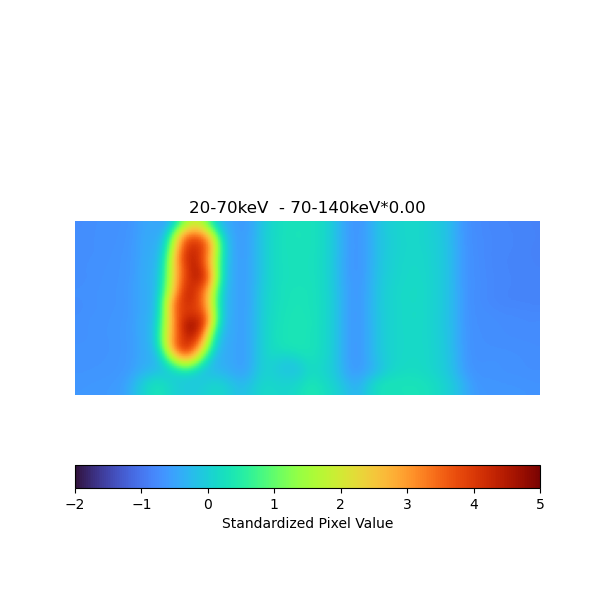

In [7]:
import mpl_interactions.ipyplot as iplt

# im1 = im1 - im1.min()
# im1 = im1 / im1.max()

# im2 = im2 - im2.min()
# im2 = im2 / im2.max()

im_low = corrected_bismuth[3]
im_hi = corrected_water[4]

def f(param1):
    temp_im = (im_low- im_hi* param1 )
    # define a standard scaler function
    def standard_scaler(x):
        return (x - x.mean()) / x.std()
    return np.rot90(standard_scaler(temp_im))

fig, ax = plt.subplots(figsize=(6,6))
controls = iplt.imshow(f, param1=(0.,2),vmin_vmax=("r", -2, 5),cmap='turbo')
plt.axis('off')
plt.colorbar(orientation='horizontal',label='Standardized Pixel Value')


with controls:
    # directly using string formatting
    # the formatting is performed in the update
    iplt.title(title="20-70keV  - 70-140keV*{param1:.2f}")
